In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load data

control = pd.read_csv("Control.csv")
treatment = pd.read_csv("Treatment.csv")

control["Group"] = "Control"
treatment["Group"] = "Treatment"

df = pd.concat([control,treatment],ignore_index=True)

print(df.shape)
df.head()

(60, 25)


,Consent,AgeGroup,Gender,Education,HiringExperience,AIExperience,Q7,Q8,Q9,Q10,...,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24_Comment,Group
0,Yes,25-34,Men,Bachelor's,Yes,No,3,2,5,4,...,5,3,4,3,3,5,4,4,The AI appeared consistent across candidates.,Control
1,Yes,18-24,Women,Bachelor's,Yes,Yes,4,4,5,5,...,3,3,4,5,5,5,5,2,One candidate may have deserved a closer review.,Control
2,Yes,35-44,Men,Bachelor's,No,Yes,3,5,4,3,...,4,5,4,4,5,4,4,5,Some decisions relied heavily on experience.,Control
3,Yes,18-24,Men,PhD,No,Yes,3,4,4,5,...,3,3,4,5,5,4,4,4,"Most decisions looked fair, though some factor...",Control
4,Yes,18-24,Men,Master's,No,Yes,3,4,4,5,...,3,4,5,4,4,4,3,5,I would like more detail on weighting of factors.,Control


In [2]:
# Fairness

df["Fairness"] = df[
    ["Q7","Q11","Q14","Q17"]
].mean(axis=1)

# Transparency

df["Transparency"] = df[
    ["Q9","Q12","Q15","Q18","Q21"]
].mean(axis=1)

# Trust

df["Trust"] = df[
    ["Q20"]
].mean(axis=1)

# Adoption

df["Adoption"] = df[
    ["Q23"]
].mean(axis=1)

In [3]:
constructs = [
    "Fairness",
    "Transparency",
    "Trust",
    "Adoption"
]

for c in constructs:
    print("\n",c)
    print(df.groupby("Group")[c].describe())


 Fairness
           count      mean       std   min     25%   50%  75%  max
Group                                                             
Control     30.0  4.066667  0.491011  3.00  3.5625  4.25  4.5  5.0
Treatment   30.0  4.333333  0.303239  3.75  4.2500  4.50  4.5  5.0

 Transparency
           count      mean       std  min  25%  50%  75%  max
Group                                                        
Control     30.0  4.080000  0.373612  3.2  4.0  4.2  4.2  4.8
Treatment   30.0  4.393333  0.334183  3.4  4.2  4.4  4.6  5.0

 Trust
           count  mean       std  min  25%  50%  75%  max
Group                                                    
Control     30.0   4.3  0.702213  3.0  4.0  4.0  5.0  5.0
Treatment   30.0   4.6  0.563242  3.0  4.0  5.0  5.0  5.0

 Adoption
           count      mean       std  min   25%  50%   75%  max
Group                                                          
Control     30.0  3.933333  0.868345  2.0  3.25  4.0  4.75  5.0
Treatment   30.

In [4]:
for c in constructs:

    control_scores = df[df.Group=="Control"][c]
    treatment_scores = df[df.Group=="Treatment"][c]

    t,p = stats.ttest_ind(
        treatment_scores,
        control_scores,
        equal_var=False
    )

    print(f"\n{c}")
    print("t =",round(t,3))
    print("p =",round(p,4))


Fairness
t = 2.531
p = 0.0147

Transparency
t = 3.424
p = 0.0011

Trust
t = 1.825
p = 0.0733

Adoption
t = 4.049
p = 0.0002


In [5]:
def cohens_d(x,y):

    nx = len(x)
    ny = len(y)

    pooled_sd = np.sqrt(
        ((nx-1)*x.std()**2 +
         (ny-1)*y.std()**2)
        /(nx+ny-2)
    )

    return (x.mean()-y.mean())/pooled_sd

for c in constructs:

    d = cohens_d(
        df[df.Group=="Treatment"][c],
        df[df.Group=="Control"][c]
    )

    print(c, round(d,3))

Fairness 0.653
Transparency 0.884
Trust 0.471
Adoption 1.046


In [6]:
df["AIExperience"] = df["AIExperience"].astype(str)

model = ols(
    'Trust ~ C(Group) + C(AIExperience) + C(Group):C(AIExperience)',
    data=df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                             sum_sq    df         F    PR(>F)
C(Group)                   2.130252   1.0  5.994679  0.017507
C(AIExperience)            3.458824   1.0  9.733373  0.002859
C(Group):C(AIExperience)   0.141176   1.0  0.397281  0.531061
Residual                  19.900000  56.0       NaN       NaN


In [7]:
def cronbach_alpha(items):

    items = items.dropna()

    item_var = items.var(axis=0, ddof=1)

    total_var = items.sum(axis=1).var(ddof=1)

    n = items.shape[1]

    alpha = (n/(n-1)) * (
        1 - item_var.sum()/total_var
    )

    return alpha

In [8]:
fairness_items = df[
    ["Q7","Q11","Q14","Q17"]
]

print(
    cronbach_alpha(fairness_items)
)

0.23957523957523996


In [9]:
transparency_items = df[
    ["Q9","Q12","Q15","Q18","Q21"]
]

print(
    cronbach_alpha(transparency_items)
)

0.49832559555521727


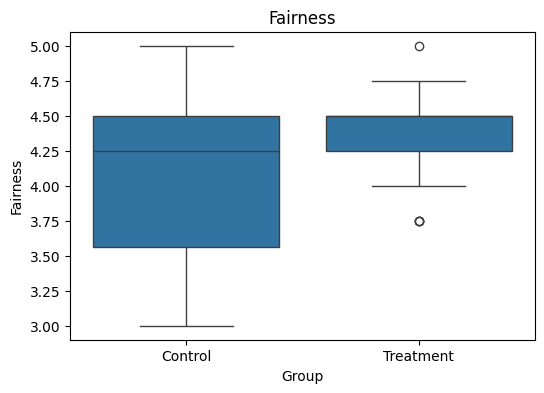

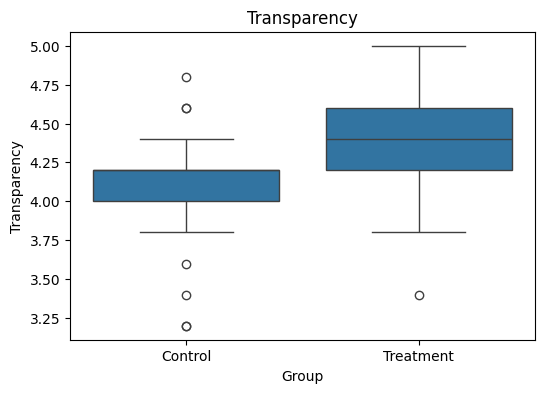

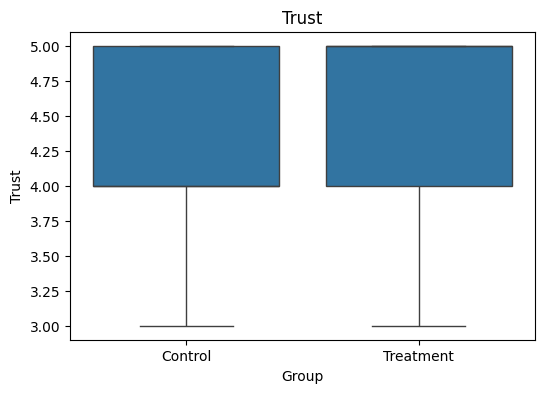

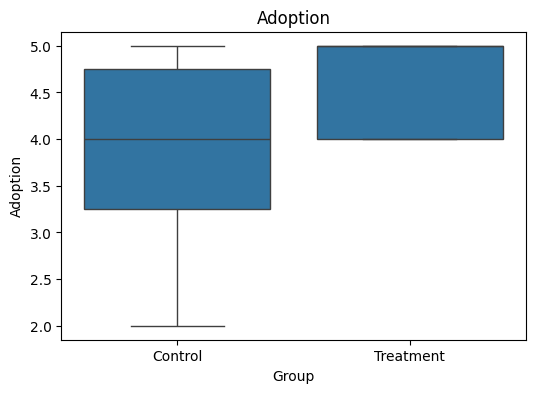

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

for c in constructs:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x="Group",
        y=c
    )

    plt.title(c)

    plt.show()